In [10]:
import pandas as pd
import numpy as np

import sys
# ВАЖНО! все задействованные функции должны быть бещ инита в своих папках
MODULE_FULL_PATH = 'C:\ROSTICS-LAB\project'

sys.path.insert(0, MODULE_FULL_PATH)
from tools.uploader import Uploader
import matplotlib.pyplot as plt

data = Uploader.generate_dynamic_features_data(
        start_date='2022-10-01',
        end_date='2025-01-31',
        num_restaurants=502,
        num_sessions_per_restaurant=1
    )

<>:6: SyntaxWarning: invalid escape sequence '\R'
<>:6: SyntaxWarning: invalid escape sequence '\R'
C:\Users\gpe9038\AppData\Local\Temp\ipykernel_27544\1739511310.py:6: SyntaxWarning: invalid escape sequence '\R'
  MODULE_FULL_PATH = 'C:\ROSTICS-LAB\project'


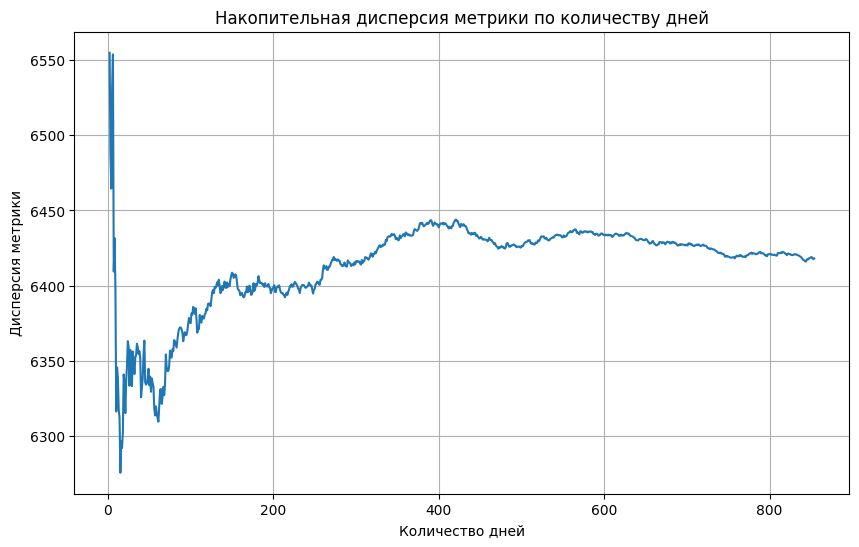

In [11]:
# Предположим, что 'data' - это ваш DataFrame с данными метрик
# Для примера, давайте вычислим дисперсию для колонки 'Метрика before'
metric = 'order_value'

# Сортируем данные по дате
data_sorted = data.sort_values('date')

# Определяем общее количество уникальных дней в датасете
total_days = data_sorted['date'].nunique()

# Инициализируем словарь для хранения результатов
variance_by_days = {}

# Вычисляем дисперсию для каждого количества дней
for num_days in range(2, total_days + 1):
    # Выбираем данные за первые num_days дней
    temp_data = data_sorted[data_sorted['date'] <= data_sorted['date'].unique()[num_days-1]]
    # Вычисляем дисперсию для выбранного промежутка
    variance = temp_data[metric].var()
    # Сохраняем результат
    variance_by_days[num_days] = variance

# Создаем график
plt.figure(figsize=(10, 6))
plt.plot(list(variance_by_days.keys()), list(variance_by_days.values()))
plt.title('Накопительная дисперсия метрики по количеству дней')
plt.xlabel('Количество дней')
plt.ylabel('Дисперсия метрики')
plt.grid(True)
plt.show()